In [202]:
import pandas as pd
import plotly.express as px
from collections import Counter
import json
import plotly
import numpy as np
from plotly.graph_objs import Scatter, Figure, Layout, Histogram, Box, Bar
from datetime import datetime
from wordcloud import WordCloud
from sklearn.linear_model import LinearRegression
import ast
import math

In [2]:
df_candidates = pd.read_csv("candidates.csv")
df_jobs = pd.read_csv("jobs.csv")
df_hist = pd.read_csv("history.csv")

In [3]:
df_jobs["create_date"] = pd.to_datetime(df_jobs["create_date"])
df_candidates["create_date"] = pd.to_datetime(df_candidates["create_date"])

In [4]:
print("Number of candidates:", len(df_candidates))
print("Number of jobs:", len(df_jobs))
print("Number of interactions:", len(df_hist))

Number of candidates: 37554
Number of jobs: 6011
Number of interactions: 42288


# Coefficients Logistic Regression

In [17]:
human_only = """
Skill Coverage = 1.04494
Contract Match = 0.73606
Expertise Area Coverage = 0.60041
Same Zip = 0.2078
Salary Gap = -0.00359
Daily Gap = -0.00411
Job Category Coverage = -0.01315
Years Bucket Match = -0.05022
"""
llm_only = """
Prog. Language Coverage = 0.54982
Job Category LLM Coverage = 0.43192
Hard Skill Coverage = 0.41563
Expertise Area LLM Coverage = 0.28842
Tool Coverage = 0.19218
N. Prev. Positions = 0.17009
Has Linkedin = 0.14915
Remote Match = 0.14171
Management Match = 0.09526
Leadership Match = 0.08933
Years Mgmt Roles = 0.07435
Internation Exp. Match = 0.06523
Client Role Match = 0.052
Startup Match = 0.04529
Has Publications = 0.04526
Seniority Gap = 0.02894
Top University = 0.02515
Freelance Match = 0.0146
Has Patents = 0.01457
Certification Coverage = 0.0099
N. Career Gaps = 0.00928
Soft Skill Coverage = 0.00016
Ongoing Study = -0.00857
Volunteer = -0.01489
Work Years Match = -0.01831
Entered Competitions = -0.01899
Multi-degree = -0.02264
Est. Salary Gap = -0.02449
With Contract Match = -0.02746
Entrepreneurial Exp. = -0.0315
Values Coverage = -0.04761
Industry Coverage = -0.06426
Large Company Match = -0.0743
Avg Job Duration = -0.07534
Diploma Match = -0.08546
Language Coverage = -0.19133
Visible Portfolio = -0.22097
N. Unique Employers = -0.22177
"""
both = """
Skill Coverage = 0.97826
Contract Match = 0.72345
Expertise Area Coverage = 0.53853
Hard Skill Coverage = 0.39343
Same Zip = 0.23215
Prog. Language Coverage = 0.23152
Expertise Area LLM Coverage = 0.22782
Tool Coverage = 0.22625
Job Category LLM Coverage = 0.1809
Management Match = 0.15769
N. Prev. Positions = 0.14764
Years Mgmt Roles = 0.13133
Remote Match = 0.12676
Has Linkedin = 0.09229
Top University = 0.06231
Client Role Match = 0.05901
Has Publications = 0.05055
Internation Exp. Match = 0.04631
Leadership Match = 0.03758
Startup Match = 0.02849
Certification Coverage = 0.02598
With Contract Match = 0.02368
Freelance Match = 0.02184
N. Career Gaps = 0.02125
Multi-degree = 0.01693
Soft Skill Coverage = 0.01412
Has Patents = 0.01122
Salary Gap = 0.00047
Job Category Coverage = 0.0001
Ongoing Study = -0.00215
Est. Salary Gap = -0.0051
Daily Gap = -0.00782
Work Years Match = -0.0092
Entrepreneurial Exp. = -0.01087
Seniority Gap = -0.01176
Entered Competitions = -0.01494
Industry Coverage = -0.02316
Large Company Match = -0.02847
Values Coverage = -0.03305
Avg Job Duration = -0.05784
Years Bucket Match = -0.05837
Volunteer = -0.0765
Diploma Match = -0.1022
Language Coverage = -0.17164
N. Unique Employers = -0.21923
Visible Portfolio = -0.28174
"""

In [18]:
human_only = {x.strip().split(" = ")[0]: float(x.strip().split(" = ")[-1]) for x in human_only.splitlines() if x.strip()}
llm_only = {x.strip().split(" = ")[0]: float(x.strip().split(" = ")[-1]) for x in llm_only.splitlines() if x.strip()}
both = {x.strip().split(" = ")[0]: float(x.strip().split(" = ")[-1]) for x in both.splitlines() if x.strip()}

# Candidates

In [20]:
df_candidates.columns

Index(['candidate_id', 'create_date', 'skills', 'expertise_area',
       'job_category', 'years_experience', 'actual_salary',
       'actual_daily_salary', 'contract_type', 'zipcode', 'source', 'llm_sex',
       'llm_nationality', 'llm_languages_spoken', 'llm_highest_diploma',
       'llm_from_top_university', 'llm_multiple_degrees',
       'llm_ongoing_education', 'llm_years_of_work_experience',
       'llm_number_of_previous_positions', 'llm_number_of_unique_employers',
       'llm_management_experience', 'llm_years_of_management_roles',
       'llm_industry_domains', 'llm_entrepreneurial_experience',
       'llm_startup_experience', 'llm_large_company_experience',
       'llm_freelance_experience', 'llm_contract_experience',
       'llm_international_work_experience', 'llm_remote_work_experience',
       'llm_average_job_duration_months', 'llm_number_of_career_gaps',
       'llm_leadership_experience', 'llm_hard_skills', 'llm_soft_skills',
       'llm_programming_languages', 'llm_to

In [228]:
", ".join(set(x.replace("llm_", "") for x in df_candidates.columns).union(set(x.replace("llm_", "") for x in df_jobs.columns)))

'contract_experience, industry_domains, is_startup, has_portfolio_or_github_or_website, entrepreneurial_experience, volunteer_experience, required_freelance_experience, company_values, in_hist, all_skills, number_of_previous_positions, required_contract_experience, is_large_company, seniority_level, number_of_career_gaps, nationality, has_linkedin, salary, age_bucket, graduation_recency, source, expertise_area, job_category, remote_work_experience, number_of_unique_employers, average_job_duration_months, contract_type, candidate_id, required_languages_spoken, salary_estimation_eur_per_year, international_work_experience, required_international_work_experience, tools_technologies, ongoing_education, years_of_management_roles, years_of_work_experience, soft_skills, required_management_experience, years_experience, remote_possible, certifications, multiple_degrees, programming_languages, required_years_of_work_experience, required_lowest_diploma, startup_experience, large_company_experien

In [22]:
print("Number of candidate features:", len(df_candidates.columns) - 1)
print("Number of LLM candidate features:", len([x for x in df_candidates.columns if x.startswith("llm_")]))

Number of candidate features: 53
Number of LLM candidate features: 43


In [26]:
print("Missing value per column:")
for column in df_candidates.columns:
    print("* ", column, df_candidates[column].isna().sum() / len(df_candidates) * 100, "%")

Missing value per column:
*  candidate_id 0.0 %
*  create_date 7.423976141023593 %
*  skills 11.370293444107151 %
*  expertise_area 7.953879746498376 %
*  job_category 26.84667412259679 %
*  years_experience 83.49576609682057 %
*  actual_salary 93.88347446343931 %
*  actual_daily_salary 97.72860414336688 %
*  contract_type 14.866592107365395 %
*  zipcode 41.553496298663255 %
*  source 14.294083186877563 %
*  llm_sex 0.0 %
*  llm_nationality 8.041753208712787 %
*  llm_languages_spoken 12.13985194653033 %
*  llm_highest_diploma 0.0 %
*  llm_from_top_university 0.0 %
*  llm_multiple_degrees 0.0 %
*  llm_ongoing_education 0.0 %
*  llm_years_of_work_experience 0.0 %
*  llm_number_of_previous_positions 0.0 %
*  llm_number_of_unique_employers 0.0 %
*  llm_management_experience 0.0 %
*  llm_years_of_management_roles 0.0 %
*  llm_industry_domains 10.683282739521756 %
*  llm_entrepreneurial_experience 0.0 %
*  llm_startup_experience 0.0 %
*  llm_large_company_experience 0.0 %
*  llm_freelance_ex

In [27]:
cands_in_hist = set(df_hist["candidate_id"])
jobs_in_hist = set(df_hist["job_id"])
df_candidates["in_hist"] = [x in cands_in_hist for x in df_candidates["candidate_id"]]
df_jobs["in_hist"] = [x in jobs_in_hist for x in df_jobs["job_id"]]

In [28]:
print("Candidates in history:", sum(df_candidates["in_hist"])/len(df_candidates) * 100, "%")
print("Jobs in history:", sum(df_jobs["in_hist"])/len(df_jobs) * 100, "%")

Candidates in history: 69.50258294722266 %
Jobs in history: 68.47446348361338 %


In [29]:
print("Job category missing values:\n",
      "In history:", df_candidates[df_candidates["in_hist"]]["job_category"].isna().mean(), "\n",
      "Not in history:", df_candidates[~df_candidates["in_hist"]]["job_category"].isna().mean())
print("Expertise Area missing values:\n",
      "In history:", df_candidates[df_candidates["in_hist"]]["expertise_area"].isna().mean(), "\n",
      "Not in history:", df_candidates[~df_candidates["in_hist"]]["expertise_area"].isna().mean())
print("Skills missing values:\n",
      "In history:", df_candidates[df_candidates["in_hist"]]["skills"].isna().mean(), "\n",
      "Not in history:", df_candidates[~df_candidates["in_hist"]]["skills"].isna().mean())
print("Years experience missing values:\n",
      "In history:", df_candidates[df_candidates["in_hist"]]["years_experience"].isna().mean(), "\n",
      "Not in history:", df_candidates[~df_candidates["in_hist"]]["years_experience"].isna().mean())
print("Contract type missing values:\n",
      "In history:", df_candidates[df_candidates["in_hist"]]["contract_type"].isna().mean(), "\n",
      "Not in history:", df_candidates[~df_candidates["in_hist"]]["contract_type"].isna().mean())

Job category missing values:
 In history: 0.24661890349028773 
 Not in history: 0.3182572251811752
Expertise Area missing values:
 In history: 0.08283207539940998 
 Not in history: 0.07203352833318781
Skills missing values:
 In history: 0.09271675414735067 
 Not in history: 0.16152973020169387
Years experience missing values:
 In history: 0.8069422627485537 
 Not in history: 0.8988038068628307
Contract type missing values:
 In history: 0.10624114018619976 
 Not in history: 0.2453505631712215


In [30]:
total = []
mape = []
for _, row in df_candidates.iterrows():
    if not pd.isna(row["actual_salary"]) and row["actual_salary"] < 200000 and row["actual_salary"] > 10000 and row["llm_estimated_salary_eur_per_year"] < 200000 and row["llm_estimated_salary_eur_per_year"] > 10000:
        total.append((row["actual_salary"] - row["llm_estimated_salary_eur_per_year"]) ** 2)
        mape.append(abs(row["actual_salary"] - row["llm_estimated_salary_eur_per_year"]) / row["actual_salary"])
        #if math.sqrt((row["actual_salary"] - row["llm_estimated_salary_eur_per_year"]) ** 2) > 50000:
        #    print(row["actual_salary"], row["llm_estimated_salary_eur_per_year"])
print("RMSE Salary candidates", math.sqrt(sum(total) / len(total)))
print("MAPE Salary candidates", sum(mape) / len(mape) * 100)

RMSE Salary candidates 22203.931844139486
MAPE Salary candidates 43.83636272000256


In [31]:
total = []
mape = []
for _, row in df_jobs.iterrows():
    if not pd.isna(row["salary"]) and row["salary"] < 200000 and row["salary"] > 10000 and row["llm_salary_estimation_eur_per_year"] < 200000 and row["llm_salary_estimation_eur_per_year"] > 10000:
        total.append((row["salary"] - row["llm_salary_estimation_eur_per_year"]) ** 2)
        mape.append(abs(row["salary"] - row["llm_salary_estimation_eur_per_year"]) / row["salary"])
        #if math.sqrt((row["actual_salary"] - row["llm_estimated_salary_eur_per_year"]) ** 2) > 50000:
        #    print(row["actual_salary"], row["llm_estimated_salary_eur_per_year"])
print("RMSE Salary jobs", math.sqrt(sum(total) / len(total)))
print("MAPE Salary jobs", sum(mape) / len(mape) * 100)

RMSE Salary candidates 15053.455620976869
MAPE Salary candidates 28.65781161972492


In [32]:
def parse_skills_column(series: pd.Series) -> pd.Series:
    def to_list(val):
        if pd.isna(val) or val is None or str(val).strip() == "":
            return list()
        return list({tok.strip().lower() for tok in str(val).split(";") if tok.strip()})

    return series.apply(to_list)

In [33]:
df_candidates["skills"] = parse_skills_column(df_candidates["skills"])
df_jobs["skills"] = parse_skills_column(df_jobs["skills"])
df_candidates["llm_skills"] = parse_skills_column(df_candidates["llm_hard_skills"])
df_jobs["llm_skills"] = parse_skills_column(df_jobs["llm_hard_skills"])
for x in ["llm_soft_skills", "llm_programming_languages", "llm_tools_technologies", "llm_certifications"]:
    df_candidates["llm_skills"] += parse_skills_column(df_candidates[x])
    df_jobs["llm_skills"] += parse_skills_column(df_jobs[x])
df_candidates["skills"] = df_candidates["skills"].apply(lambda skills: set(skills))
df_jobs["skills"] = df_jobs["skills"].apply(lambda skills: set(skills))
df_candidates["llm_skills"] = df_candidates["llm_skills"].apply(lambda skills: set(skills))
df_jobs["llm_skills"] = df_jobs["llm_skills"].apply(lambda skills: set(skills))

In [34]:
total_recall = []
total_precision = []
for _, row in df_candidates.iterrows():
    s1 = row["skills"]
    s2 = row["llm_skills"]
    if s1:
        total_recall.append(len(s1.intersection(s2)) / len(s1))
    if s1 and s2:
        total_precision.append(len(s1.intersection(s2)) / len(s2))
print("Recall Skills Candidates:", sum(total_recall) / len(total_recall))
print("Precision Skills Candidates:", sum(total_precision) / len(total_precision))

Recall Skills Candidates: 0.2801556130738099
Precision Skills Candidates: 0.14629748587213717


In [35]:
total_recall = []
total_precision = []
for _, row in df_jobs.iterrows():
    s1 = row["skills"]
    s2 = row["llm_skills"]
    if s1:
        total_recall.append(len(s1.intersection(s2)) / len(s1))
    if s1 and s2:
        total_precision.append(len(s1.intersection(s2)) / len(s2))
print("Recall Skills Jobs:", sum(total_recall) / len(total_recall))
print("Precision Skills Jobs:", sum(total_precision) / len(total_precision))

Recall Skills Jobs: 0.4689868026362328
Precision Skills Jobs: 0.09944607135852096


In [36]:
df_candidates["job_category"] = parse_skills_column(df_candidates["job_category"])
df_candidates["expertise_area"] = parse_skills_column(df_candidates["expertise_area"])
df_candidates["llm_job_category"] = parse_skills_column(df_candidates["llm_job_category"])
df_candidates["llm_expertise_area"] = parse_skills_column(df_candidates["llm_expertise_area"])

In [38]:
df_jobs["job_category"] = parse_skills_column(df_jobs["job_category"])
df_jobs["expertise_area"] = parse_skills_column(df_jobs["expertise_area"])
df_jobs["llm_job_category"] = parse_skills_column(df_jobs["llm_job_category"])
df_jobs["llm_expertise_area"] = parse_skills_column(df_jobs["llm_expertise_area"])

In [39]:
df_candidates["job_category"] = df_candidates["job_category"].apply(lambda skills: set(skills))
df_candidates["expertise_area"] = df_candidates["expertise_area"].apply(lambda skills: set(skills))
df_candidates["llm_job_category"] = df_candidates["llm_job_category"].apply(lambda skills: set(skills))
df_candidates["llm_expertise_area"] = df_candidates["llm_expertise_area"].apply(lambda skills: set(skills))

In [40]:
df_jobs["job_category"] = df_jobs["job_category"].apply(lambda skills: set(skills))
df_jobs["expertise_area"] = df_jobs["expertise_area"].apply(lambda skills: set(skills))
df_jobs["llm_job_category"] = df_jobs["llm_job_category"].apply(lambda skills: set(skills))
df_jobs["llm_expertise_area"] = df_jobs["llm_expertise_area"].apply(lambda skills: set(skills))

In [41]:
total_recall = []
total_precision = []
for _, row in df_candidates.iterrows():
    s1 = row["job_category"]
    s2 = row["llm_job_category"]
    if s1:
        total_recall.append(len(s1.intersection(s2)) / len(s1))
    if s1 and s2:
        total_precision.append(len(s1.intersection(s2)) / len(s2))
print("Job Category Candidate Recall:", sum(total_recall) / len(total_recall))
print("Job Category Candidate Precision:", sum(total_precision) / len(total_precision))

Job Category Candidate Recall: 0.21443926864809948
Job Category Candidate Precision: 0.23048056369250255


In [42]:
total_recall = []
total_precision = []
for _, row in df_candidates.iterrows():
    s1 = row["expertise_area"]
    s2 = row["llm_expertise_area"]
    if s1:
        total_recall.append(len(s1.intersection(s2)) / len(s1))
    if s1 and s2:
        total_precision.append(len(s1.intersection(s2)) / len(s2))
print("Expertise Area Candidate Recall:", sum(total_recall) / len(total_recall))
print("Expertise Area Candidate Precision:", sum(total_precision) / len(total_precision))

Expertise Area Candidate Recall: 0.5289611479156421
Expertise Area Candidate Precision: 0.3748195792113109


In [43]:
total_recall = []
total_precision = []
for _, row in df_jobs.iterrows():
    s1 = row["job_category"]
    s2 = row["llm_job_category"]
    if s1:
        total_recall.append(len(s1.intersection(s2)) / len(s1))
    if s1 and s2:
        total_precision.append(len(s1.intersection(s2)) / len(s2))
print("Job Category Jobs Recall:", sum(total_recall) / len(total_recall))
print("Job Category Jobs Precision:", sum(total_precision) / len(total_precision))

Job Category Jobs Recall: 0.510951642099819
Job Category Jobs Precision: 0.3318064182194617


In [44]:
total_recall = []
total_precision = []
for _, row in df_jobs.iterrows():
    s1 = row["expertise_area"]
    s2 = row["llm_expertise_area"]
    if s1:
        total_recall.append(len(s1.intersection(s2)) / len(s1))
    if s1 and s2:
        total_precision.append(len(s1.intersection(s2)) / len(s2))
print("Expertise Area Jobs Recall:", sum(total_recall) / len(total_recall))
print("Expertise Area Jobs Precision:", sum(total_precision) / len(total_precision))

Expertise Area Jobs Recall: 0.7826104321431424
Expertise Area Jobs Precision: 0.4112735698306168


In [238]:
for col in df_candidates.columns:
    if type(df_candidates[col][0]) is set:
        tmp = set(y for x in df_candidates[col] for y in x)
    else:
        tmp = df_candidates[col].unique()
    if len(tmp) < 100:
        print("    \\item", col, ":", ". Examples of values: ", ", ".join(list(sorted(str(x) for x in tmp))[:10]))
    else:
        print("    \\item", col, ":")

    \item candidate_id :
    \item create_date :
    \item skills :
    \item expertise_area : . Examples of values:  _rare_expertise_area_, cloud & infrastructure, data, development, electronics, functional, management, mobile, product & design, qa
    \item job_category : . Examples of values:  _rare_job_category_, agile coach, ai engineer, analog design engineer, application engineer, asic engineer, backend developer, business analyst, chief data officer (cdo), cpo/head of product
    \item years_experience : . Examples of values:  +6 years, 0-2 years, 3-6 years, nan
    \item actual_salary :
    \item actual_daily_salary :
    \item contract_type : . Examples of values:  fixed-term;freelance, fixed-term;freelance;permanent, fixed-term;permanent, freelance, freelance;permanent, internship, nan, permanent
    \item zipcode : . Examples of values:  0.0, 1.0, 10.0, 11.0, 12.0, 13.0, 14.0, 16.0, 17.0, 18.0
    \item source : . Examples of values:  0.0, 1.0, 10.0, 11.0, 12.0, 13.0, 14.0,

In [231]:
print("Average of associated manual skills to candidates:", sum([len(x) for x in df_candidates["skills"]]) / len(df_candidates))
print("Average of associated skills to candidates:", sum([len(x) for x in df_candidates["all_skills"]]) / len(df_candidates))

Average of associated manual skills to candidates: 4.579565425786867
Average of associated skills to candidates: 13.145470522447676


# Jobs

In [74]:
df_jobs.columns

Index(['job_id', 'create_date', 'job_category', 'skills', 'contract_type',
       'expertise_area', 'years_experience', 'zipcode', 'salary', 'daily_rate',
       'source', 'llm_remote_possible', 'llm_industry_domains',
       'llm_company_values', 'llm_seniority_level',
       'llm_salary_estimation_eur_per_year', 'llm_required_languages_spoken',
       'llm_required_lowest_diploma', 'llm_required_years_of_work_experience',
       'llm_required_management_experience', 'llm_is_startup',
       'llm_is_large_company', 'llm_required_freelance_experience',
       'llm_required_contract_experience',
       'llm_required_international_work_experience',
       'llm_required_leadership_experience', 'llm_hard_skills',
       'llm_soft_skills', 'llm_programming_languages',
       'llm_tools_technologies', 'llm_certifications', 'llm_expertise_area',
       'llm_job_category', 'llm_client_facing_role', 'in_hist', 'llm_skills'],
      dtype='object')

In [75]:
print("Number of candidate features:", len(df_jobs.columns) - 1)
print("Number of LLM candidate features:", len([x for x in df_jobs.columns if x.startswith("llm_")]))

Number of candidate features: 35
Number of LLM candidate features: 24


In [239]:
for col in df_jobs.columns:
    if type(df_jobs[col][0]) is set:
        tmp = set(y for x in df_jobs[col] for y in x)
    else:
        tmp = df_jobs[col].unique()
    if len(tmp) < 100:
        print("    \\item", col, ":", ". Examples of values: ", ", ".join(list(sorted(str(x) for x in tmp))[:10]))
    else:
        print("    \\item", col, ":")

    \item job_id :
    \item create_date :
    \item job_category : . Examples of values:  _rare_job_category_, asic engineer, backend developer, business analyst, data engineer, devops engineer, electronics engineer, embedded system engineer, embedded systems developer, engineering manager
    \item skills : . Examples of values:  .net, _rare_skill_, agile method, amazon web services, android, angular.js, asp.net, automation, automatized tests, azure
    \item contract_type : . Examples of values:  fixed-term, freelance, permanent
    \item expertise_area : . Examples of values:  _rare_expertise_area_, cloud & infrastructure, data, development, electronics, functional, management, mobile, product & design, qa
    \item years_experience : . Examples of values:  +6 years, 0-2 years, 3-6 years, nan
    \item zipcode : . Examples of values:   , 13, 14, 25, 28, 31, 33, 34, 35, 38
    \item salary :
    \item daily_rate :
    \item source : . Examples of values:  23.0, 24.0, 25.0, 26.0, 27.

In [26]:
print("Missing value per column:")
for column in df_candidates.columns:
    print("* ", column, df_candidates[column].isna().sum() / len(df_candidates) * 100, "%")

Missing value per column:
*  candidate_id 0.0 %
*  create_date 7.423976141023593 %
*  skills 11.370293444107151 %
*  expertise_area 7.953879746498376 %
*  job_category 26.84667412259679 %
*  years_experience 83.49576609682057 %
*  actual_salary 93.88347446343931 %
*  actual_daily_salary 97.72860414336688 %
*  contract_type 14.866592107365395 %
*  zipcode 41.553496298663255 %
*  source 14.294083186877563 %
*  llm_sex 0.0 %
*  llm_nationality 8.041753208712787 %
*  llm_languages_spoken 12.13985194653033 %
*  llm_highest_diploma 0.0 %
*  llm_from_top_university 0.0 %
*  llm_multiple_degrees 0.0 %
*  llm_ongoing_education 0.0 %
*  llm_years_of_work_experience 0.0 %
*  llm_number_of_previous_positions 0.0 %
*  llm_number_of_unique_employers 0.0 %
*  llm_management_experience 0.0 %
*  llm_years_of_management_roles 0.0 %
*  llm_industry_domains 10.683282739521756 %
*  llm_entrepreneurial_experience 0.0 %
*  llm_startup_experience 0.0 %
*  llm_large_company_experience 0.0 %
*  llm_freelance_ex

In [232]:
print("Average of associated manual skills to jobs:", sum([len(x) for x in df_jobs["skills"]]) / len(df_jobs))
print("Average of associated skills to jobs:", sum([len(x) for x in df_jobs["all_skills"]]) / len(df_jobs))

Average of associated manual skills to jobs: 1.8279820329396108
Average of associated skills to jobs: 10.3029446015638


In [240]:
FEATURE_NAMES = [
    # overlaps
    "Skill Coverage", "Hard Skill Coverage", "Soft Skill Coverage", "Prog. Language Coverage", "Tool Coverage",
    "Certification Coverage", "Expertise Area Coverage", "Job Category Coverage",
    "Expertise Area LLM Coverage", "Job Category LLM Coverage",
    "Industry Coverage", "Values Coverage",
    "Language Coverage",
    # modality flags
    "Contract Match", "Remote Match", "Freelance Match", "With Contract Match",
    # profile fit
    "Years Bucket Match", "Management Match", "Leadership Match", "Startup Match", "Large Company Match",
    "Internation Exp. Match", "Client Role Match", "Seniority Gap", "Diploma Match",
    # compensation
    "Salary Gap", "Daily Gap", "Est. Salary Gap",
    # geo & source
    "Same Zip",
    # work‑exp req
    "Work Years Match",
    # candidate llm flags (10)
    "Top University", "Multi-degree", "Ongoing Study", "Entrepreneurial Exp.", "Volunteer",
    "Has Publications", "Has Patents", "Visible Portfolio", "Has Linkedin", "Entered Competitions",
    # numeric counts (5)
    "N. Prev. Positions", "N. Unique Employers", "Years Mgmt Roles",
    "Avg Job Duration", "N. Career Gaps",
    # temporal trio
    "Entity Delta Days", "Rec. Delta Days", "Existed Before"
]
for name in FEATURE_NAMES:
    print("    \\item", name + ": ")

    \item Skill Coverage: 
    \item Hard Skill Coverage: 
    \item Soft Skill Coverage: 
    \item Prog. Language Coverage: 
    \item Tool Coverage: 
    \item Certification Coverage: 
    \item Expertise Area Coverage: 
    \item Job Category Coverage: 
    \item Expertise Area LLM Coverage: 
    \item Job Category LLM Coverage: 
    \item Industry Coverage: 
    \item Values Coverage: 
    \item Language Coverage: 
    \item Contract Match: 
    \item Remote Match: 
    \item Freelance Match: 
    \item With Contract Match: 
    \item Years Bucket Match: 
    \item Management Match: 
    \item Leadership Match: 
    \item Startup Match: 
    \item Large Company Match: 
    \item Internation Exp. Match: 
    \item Client Role Match: 
    \item Seniority Gap: 
    \item Diploma Match: 
    \item Salary Gap: 
    \item Daily Gap: 
    \item Est. Salary Gap: 
    \item Same Zip: 
    \item Work Years Match: 
    \item Top University: 
    \item Multi-degree: 
    \item Ongoing Study: 

# History

In [45]:
for x in df_hist.columns:
    if "_date" in x and "end_of_process_date" not in x and x != "job_offer_opening_date":
        df_hist[x] = pd.to_datetime(df_hist[x])

In [46]:
columns_date = [x for x in df_hist.columns if "_date" in x and "end_of_process_date" not in x and x != "job_offer_opening_date"]
df_all_dates = df_hist[["candidate_id", "job_id"] + columns_date].copy()

In [47]:
lifetime_application = df_all_dates[columns_date].max(axis=1) - df_all_dates[columns_date].min(axis=1)
df_dates = df_all_dates[lifetime_application > pd.Timedelta(days=0)]

In [48]:
lifetime_candidate = df_dates.groupby(by="candidate_id").max()[columns_date].max(axis=1) - df_dates.groupby(by="candidate_id").min()[columns_date].min(axis=1)

In [49]:
print("Median lifetime of a candidate:", lifetime_candidate.median())
print("Mean lifetime of a candidate:", lifetime_candidate.mean())
print("Max lifetime of a candidate:", lifetime_candidate.max())

Median lifetime of a candidate: 10 days 00:00:00
Mean lifetime of a candidate: 88 days 07:40:54.126452630
Max lifetime of a candidate: 2421 days 00:00:00


In [50]:
lifetime_job = df_dates.groupby(by="job_id").max()[columns_date].max(axis=1) - df_dates.groupby(by="job_id").min()[columns_date].min(axis=1)

In [51]:
print("Median lifetime of a job:", lifetime_job.median())
print("Mean lifetime of a job:", lifetime_job.mean())
print("Max lifetime of a job:", lifetime_job.max())

Median lifetime of a job: 24 days 00:00:00
Mean lifetime of a job: 42 days 12:32:49.685767098
Max lifetime of a job: 1453 days 00:00:00


In [52]:
lifetime_application = df_dates[columns_date].max(axis=1) - df_dates[columns_date].min(axis=1)

In [53]:
print("Median lifetime of an application:", lifetime_application.median())
print("Mean lifetime of an application:", lifetime_application.mean())
print("Max lifetime of an application:", lifetime_application.max())

Median lifetime of an application: 8 days 00:00:00
Mean lifetime of an application: 11 days 13:36:21.530343007
Max lifetime of an application: 1453 days 00:00:00


In [54]:
df_dates[lifetime_application > pd.Timedelta(days=1000)]

,candidate_id,job_id,spontaneous_application_date,shortlist_date,qualification_date,resume_sent_to_company_date,1st_interview_date,2nd_interview_date,3rd_interview_date,4th_interview_date,job_offer_proposed_date,job_offer_accepted_date
634,3854,1225,NaT,2018-09-16,2022-09-08,2022-09-08,NaT,NaT,NaT,NaT,NaT,NaT
4716,1695,390,NaT,2020-05-28,2020-05-28,NaT,NaT,NaT,NaT,NaT,2023-07-07,2023-07-08


In [55]:
print("Missing value per column:")
for column in df_hist.columns:
    print("* ", column, df_hist[column].isna().sum())

Missing value per column:
*  application_id 0
*  candidate_id 0
*  job_id 0
*  spontaneous_application_date 38871
*  shortlist_date 4554
*  qualification_date 18053
*  resume_sent_to_company_date 35170
*  1st_interview_date 39475
*  2nd_interview_date 41463
*  3rd_interview_date 42059
*  4th_interview_date 42220
*  job_offer_proposed_date 41389
*  job_offer_accepted_date 41431
*  end_of_process_date 31240
*  last_stage_reached 0
*  application_source 32216


In [56]:
print("How many reach each step:")
for column in df_hist.columns:
    print("* ", column, (~df_hist[column].isna()).sum())

How many reach each step:
*  application_id 42288
*  candidate_id 42288
*  job_id 42288
*  spontaneous_application_date 3417
*  shortlist_date 37734
*  qualification_date 24235
*  resume_sent_to_company_date 7118
*  1st_interview_date 2813
*  2nd_interview_date 825
*  3rd_interview_date 229
*  4th_interview_date 68
*  job_offer_proposed_date 899
*  job_offer_accepted_date 857
*  end_of_process_date 11048
*  last_stage_reached 42288
*  application_source 10072


In [60]:
df_all_dates["min_date"] = df_all_dates[columns_date].min(axis=1)

In [61]:
df_all_dates["min_date"].max()

Timestamp('2025-04-21 00:00:00')

In [62]:
job_diff = pd.merge(df_all_dates[["job_id", "min_date"]], df_jobs[["job_id", "create_date"]])

In [63]:
job_diff["diff"] = job_diff["min_date"] - job_diff["create_date"]

In [64]:
print("Median time difference between shortlist and job", job_diff["diff"].median())

Median time difference between shortlist and job 23 days 00:00:00


In [65]:
print((1 - sum(df_hist["spontaneous_application_date"].isna()) / len(df_hist)) * 100, "% applications are spontaneous")

8.08030646992054 % applications are spontaneous


In [66]:
print((1 - sum(df_hist["shortlist_date"].isna()) / len(df_hist)) * 100, "% applications are done by recruiters")

89.23098751418841 % applications are done by recruiters


In [67]:
columns_date_bis = columns_date[:]
columns_date_bis.remove("spontaneous_application_date")

In [68]:
tmp = df_hist[~df_hist["spontaneous_application_date"].isna()][columns_date_bis].isna().all(axis=1)
print("Among spontaneous applications,", sum(tmp) / len(tmp) * 100, "% do not continue")

Among spontaneous applications, 93.94205443371378 % do not continue


# Visualization

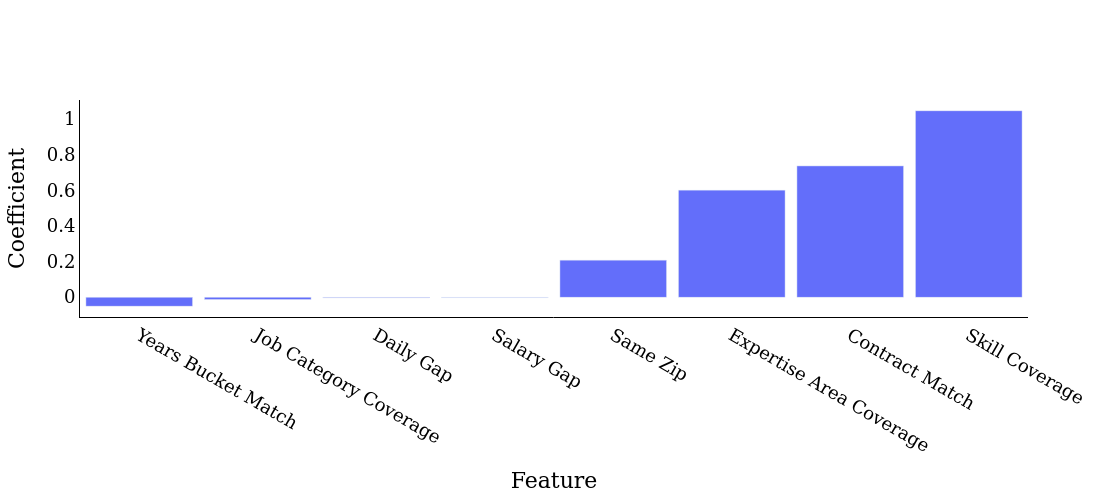

In [213]:
tmp = sorted(list(sorted(human_only.items(), key=lambda x: -abs(x[1])))[:10], key=lambda x: x[1])
layout = Layout(
    font=dict(family='Latin Modern Math', size=18, color="black"),
    xaxis=dict(
        title='Feature',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    yaxis=dict(
        title='Coefficient',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    legend=dict(x=0.4, y=1),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    width=600, height=500, bargap=0.1
)
data = [
    Bar(x=[x[0] for x in tmp], y=[x[1] for x in tmp])
]
fig = Figure(data=data, layout=layout)
fig.show()
fig.write_image("human_coeff.pdf")

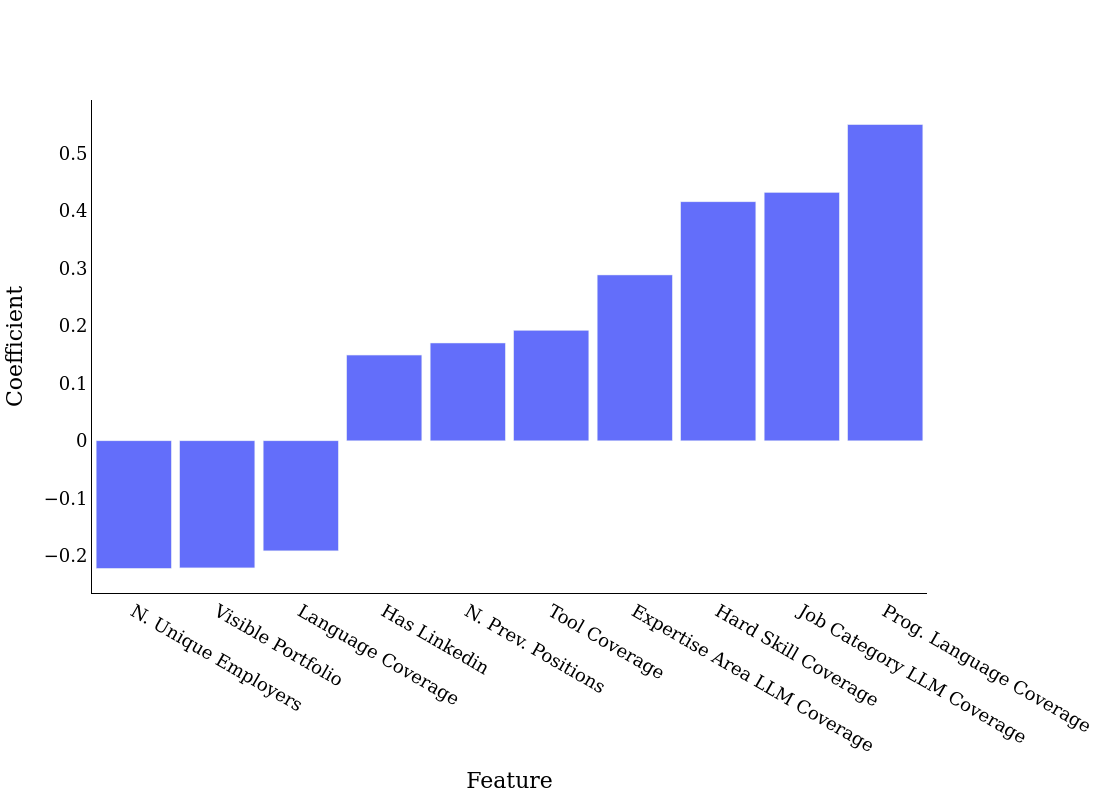

In [216]:
tmp = sorted(list(sorted(llm_only.items(), key=lambda x: -abs(x[1])))[:10], key=lambda x: x[1])
layout = Layout(
    font=dict(family='Latin Modern Math', size=18, color="black"),
    xaxis=dict(
        title='Feature',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    yaxis=dict(
        title='Coefficient',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    legend=dict(x=0.4, y=1),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    width=600, height=800, bargap=0.1
)
data = [
    Bar(x=[x[0] for x in tmp], y=[x[1] for x in tmp])
]
fig = Figure(data=data, layout=layout)
fig.show()
fig.write_image("llm_coeff.pdf")

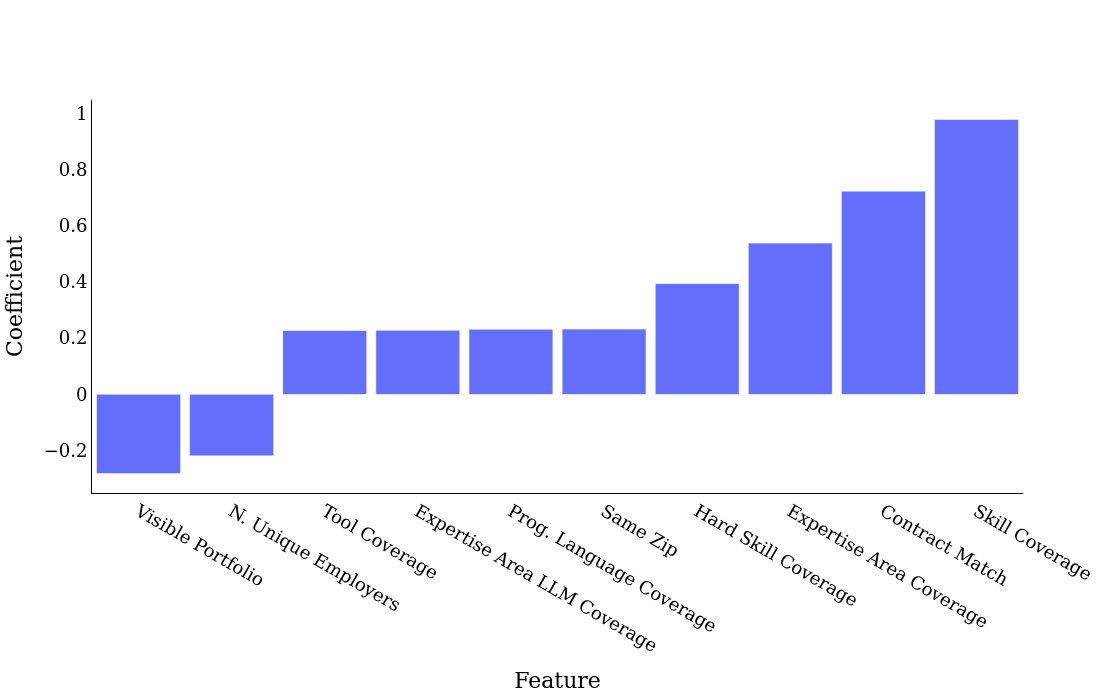

In [218]:
tmp = sorted(list(sorted(both.items(), key=lambda x: -abs(x[1])))[:10], key=lambda x: x[1])
layout = Layout(
    font=dict(family='Latin Modern Math', size=18, color="black"),
    xaxis=dict(
        title='Feature',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    yaxis=dict(
        title='Coefficient',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    legend=dict(x=0.4, y=1),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    width=600, height=700, bargap=0.1
)
data = [
    Bar(x=[x[0] for x in tmp], y=[x[1] for x in tmp])
]
fig = Figure(data=data, layout=layout)
fig.show()
fig.write_image("both_coeff.pdf")

In [219]:
all_skills_candidates = list(df_candidates["skills"])
for i, x in enumerate(df_candidates["llm_skills"]):
    all_skills_candidates[i] = all_skills_candidates[i].union(x)
df_candidates["all_skills"] = all_skills_candidates

In [220]:
all_skills_jobs = list(df_jobs["skills"])
for i, x in enumerate(df_jobs["llm_skills"]):
    all_skills_jobs[i] = all_skills_jobs[i].union(x)
df_jobs["all_skills"] = all_skills_jobs

In [221]:
tmp = []
for x in df_candidates["skills"]:
    tmp2 = []
    if type(x) is str:
        for y in x.split(";"):
            if y not in tmp2:
                tmp2.append(y)
    elif type(x) is set:
        for y in x:
            if y not in tmp2:
                tmp2.append(y)
    tmp += tmp2
print("Number of manual skills per candidate", len(tmp)/len(df_candidates))
Counter(tmp).most_common(30)

Number of manual skills per candidate 4.579565425786867


[('javascript', 8858),
 ('php', 8331),
 ('python', 6555),
 ('linux', 6199),
 ('java', 5296),
 ('project management', 4981),
 ('sql', 4963),
 ('c++', 4733),
 ('react.js', 4212),
 ('c', 4032),
 ('mysql', 3709),
 ('node.js', 3708),
 ('git', 3681),
 ('windows', 3056),
 ('database', 2920),
 ('angular.js', 2673),
 ('amazon web services', 2432),
 ('c#', 2305),
 ('jquery', 2117),
 ('scrum', 1845),
 ('agile method', 1832),
 ('digital marketing', 1796),
 ('vue.js', 1780),
 ('electronics', 1771),
 ('docker', 1637),
 ('matlab', 1614),
 ('symfony', 1528),
 ('typescript', 1460),
 ('android', 1403),
 ('ios', 1346)]

In [222]:
tmp = []
for x in df_candidates["all_skills"]:
    tmp2 = []
    if type(x) is str:
        for y in x.split(";"):
            if y not in tmp2:
                tmp2.append(y)
    elif type(x) is set:
        for y in x:
            if y not in tmp2:
                tmp2.append(y)
    tmp += tmp2
print("Number of skills per candidate", len(tmp)/len(df_candidates))
Counter(tmp).most_common(30)

Number of skills per candidate 13.145470522447676


[('communication', 27234),
 ('_rare_skill_', 20301),
 ('teamwork', 17296),
 ('javascript', 14564),
 ('python', 12798),
 ('java', 12722),
 ('problem-solving', 12267),
 ('team management', 11354),
 ('php', 10944),
 ('project management', 8517),
 ('sql', 8291),
 ('git', 7989),
 ('linux', 7333),
 ('c++', 7305),
 ('mysql', 7163),
 ('_rare_certification_', 6605),
 ('c', 5786),
 ('docker', 5026),
 ('node.js', 4632),
 ('react.js', 4426),
 ('leadership', 4161),
 ('c#', 3823),
 ('problem solving', 3755),
 ('windows', 3692),
 ('html', 3547),
 ('jquery', 3376),
 ('css', 3302),
 ('symfony', 3298),
 ('jira', 3182),
 ('time management', 3040)]

In [223]:
tmp = []
for x in df_jobs["skills"]:
    if type(x) is str:
        for y in x.split(";"):
            tmp.append(y)
    elif type(x) is set:
        for y in x:
            tmp.append(y)
print("Average number of manual skills per job", len(tmp)/len(df_jobs))
Counter(tmp).most_common(20)

Average number of manual skills per job 1.8279820329396108


[('php', 1102),
 ('react.js', 869),
 ('javascript', 717),
 ('node.js', 645),
 ('_rare_skill_', 591),
 ('python', 355),
 ('java', 320),
 ('angular.js', 292),
 ('automation', 250),
 ('vue.js', 240),
 ('j2ee', 239),
 ('c++', 238),
 ('android', 234),
 ('database', 228),
 ('linux', 225),
 ('moa', 216),
 ('cloud', 215),
 ('c', 214),
 ('ios', 203),
 ('amazon web services', 185)]

In [224]:
tmp = []
for x in df_jobs["all_skills"]:
    if type(x) is str:
        for y in x.split(";"):
            tmp.append(y)
    elif type(x) is set:
        for y in x:
            tmp.append(y)
print("Average number of manual skills per job", len(tmp)/len(df_jobs))
Counter(tmp).most_common(20)

Average number of manual skills per job 10.3029446015638


[('_rare_skill_', 4924),
 ('communication', 3925),
 ('teamwork', 3925),
 ('problem-solving', 2977),
 ('javascript', 2619),
 ('php', 1388),
 ('autonomy', 1166),
 ('docker', 1125),
 ('adaptability', 1053),
 ('git', 1011),
 ('react.js', 949),
 ('node.js', 808),
 ('aws', 781),
 ('python', 767),
 ('mysql', 723),
 ('symfony', 717),
 ('react', 684),
 ('java', 634),
 ('kubernetes', 618),
 ('linux', 577)]

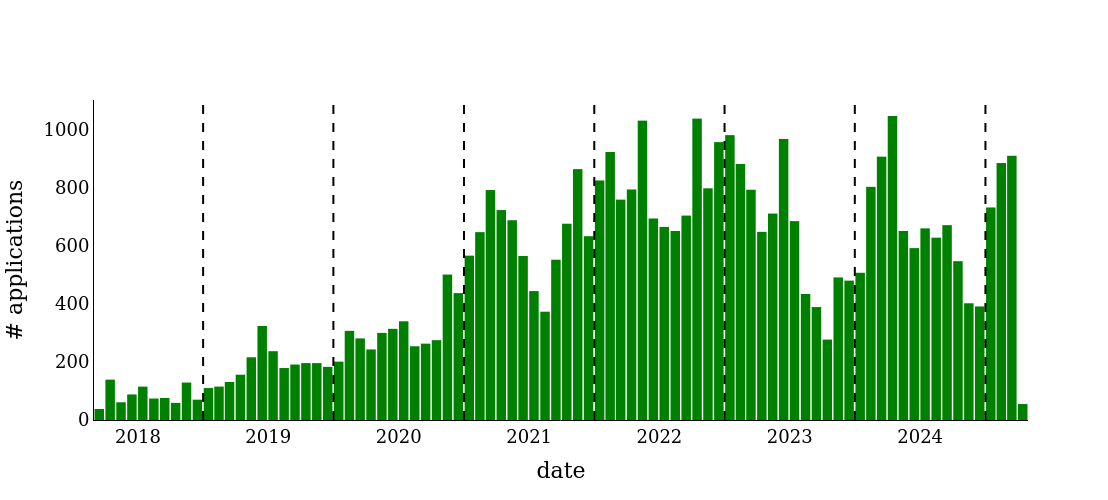

In [225]:
layout = Layout(
  #  title='Comparisation Performance With Rule Order Optimization',
    font=dict(family='Latin Modern Math', size=18, color="black"),
    xaxis=dict(
        title='date',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    yaxis=dict(
        title='# applications',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    legend=dict(x=0.4, y=1),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    width=600, height=500, bargap=0.1
)
data = [
    Histogram(x=df_all_dates["min_date"], marker_color="green")
]
fig = Figure(data=data, layout=layout)
for x in range(2019, 2026):
    fig.add_vline(x=datetime(x, 1, 1), line_width=2, line_dash="dash", line_color="black")
fig.update_xaxes(showgrid=True, ticklabelmode="period", dtick="M12", tickformat="%Y")
fig.show()
fig.write_image("applications_timeline.pdf")

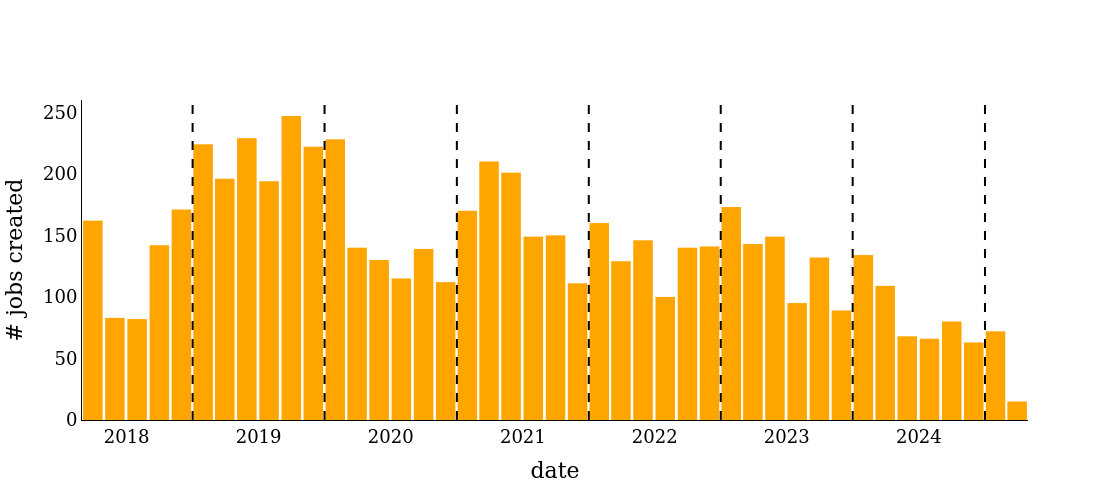

In [226]:
layout = Layout(
  #  title='Comparisation Performance With Rule Order Optimization',
    font=dict(family='Latin Modern Math', size=18, color="black"),
    xaxis=dict(
        title='date',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    yaxis=dict(
        title='# jobs created',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    legend=dict(x=0.4, y=1),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    width=600, height=500, bargap=0.1
)
data = [
    Histogram(x=df_jobs["create_date"], marker_color="orange")
]
fig = Figure(data=data, layout=layout)
for x in range(2019, 2026):
    fig.add_vline(x=datetime(x, 1, 1), line_width=2, line_dash="dash", line_color="black")
fig.update_xaxes(showgrid=True, ticklabelmode="period", dtick="M12", tickformat="%Y")
fig.show()
fig.write_image("jobs_timeline.pdf")

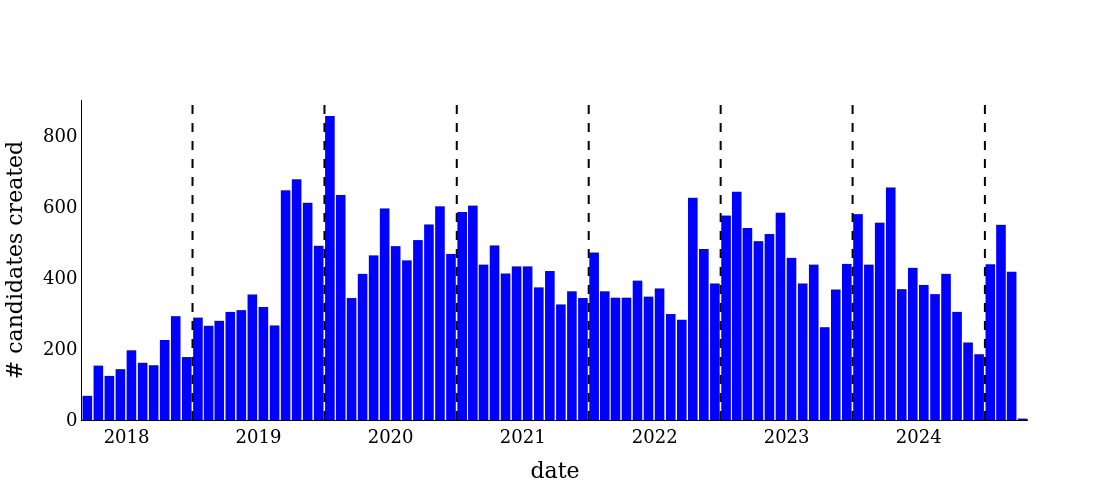

In [227]:
layout = Layout(
  #  title='Comparisation Performance With Rule Order Optimization',
    font=dict(family='Latin Modern Math', size=18, color="black"),
    xaxis=dict(
        title='date',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    yaxis=dict(
        title='# candidates created',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    legend=dict(x=0.4, y=1),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    width=600, height=500, bargap=0.1
)
data = [
    Histogram(x=df_candidates["create_date"].dropna(), marker_color="blue")
]
fig = Figure(data=data, layout=layout)
for x in range(2019, 2026):
    fig.add_vline(x=datetime(x, 1, 1), line_width=2, line_dash="dash", line_color="black")
fig.update_xaxes(showgrid=True, ticklabelmode="period", dtick="M12", tickformat="%Y")
fig.show()
fig.write_image("candidates_timeline.pdf")

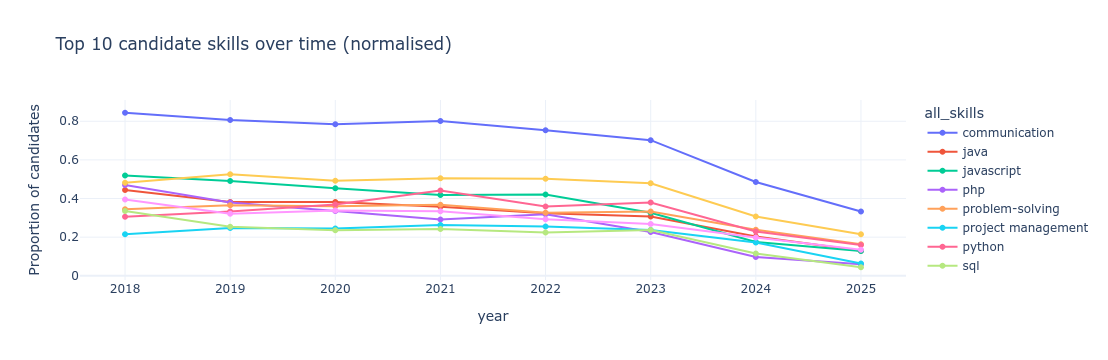

In [117]:
# keep only year and skills
cand_skills = (
    df_candidates[["create_date", "all_skills"]]
      .assign(year=lambda df: df["create_date"].dt.year)
      .explode("all_skills")
      .query("all_skills != '_rare_skill_'")
)

# ---------- 2. Total candidates per year ----------
totals = (
    df_candidates.assign(year=lambda df: df["create_date"].dt.year)
              .groupby("year")
              .size()
              .rename("n_candidates")
)

# ---------- 3. Aggregate & normalise ----------
TOP_N = 10
top_skills = (
    cand_skills["all_skills"]
      .value_counts()
      .head(TOP_N)
      .index
)

freq = (
    cand_skills
      .query("all_skills in @top_skills")
      .groupby(["year", "all_skills"])
      .size()
      .rename("count")
      .reset_index()
      .merge(totals, on="year")
      .assign(freq=lambda df: df["count"] / df["n_candidates"])  # proportion
)

# ---------- 4. Plot ----------
fig = px.line(
    freq,
    x="year",
    y="freq",
    color="all_skills",
    markers=True,
    title=f"Top {TOP_N} candidate skills over time (normalised)",
    labels={"freq": "Proportion of candidates"}
)
fig.update_layout(template="plotly_white")
fig.show()


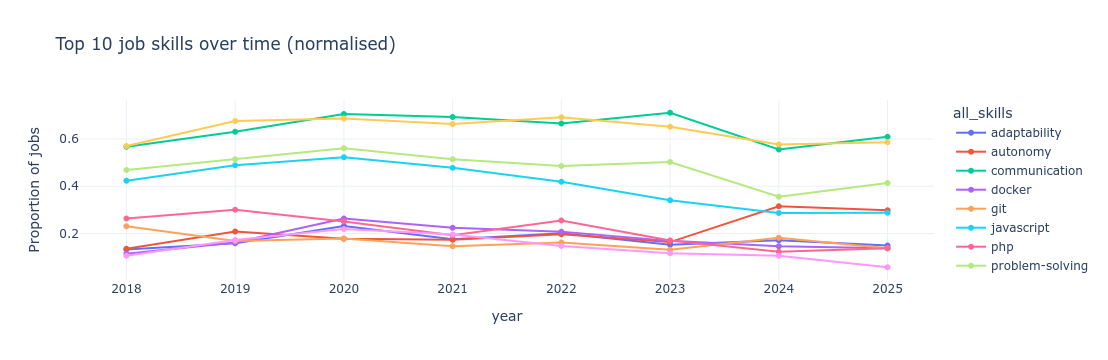

In [118]:
# keep only year and skills
cand_skills = (
    df_jobs[["create_date", "all_skills"]]
      .assign(year=lambda df: df["create_date"].dt.year)
      .explode("all_skills")
      .query("all_skills != '_rare_skill_'")
)

# ---------- 2. Total candidates per year ----------
totals = (
    df_jobs.assign(year=lambda df: df["create_date"].dt.year)
              .groupby("year")
              .size()
              .rename("n_candidates")
)

# ---------- 3. Aggregate & normalise ----------
TOP_N = 10
top_skills = (
    cand_skills["all_skills"]
      .value_counts()
      .head(TOP_N)
      .index
)

freq = (
    cand_skills
      .query("all_skills in @top_skills")
      .groupby(["year", "all_skills"])
      .size()
      .rename("count")
      .reset_index()
      .merge(totals, on="year")
      .assign(freq=lambda df: df["count"] / df["n_candidates"])  # proportion
)

# ---------- 4. Plot ----------
fig = px.line(
    freq,
    x="year",
    y="freq",
    color="all_skills",
    markers=True,
    title=f"Top {TOP_N} job skills over time (normalised)",
    labels={"freq": "Proportion of jobs"}
)
fig.update_layout(template="plotly_white")
fig.show()


/tmp/ipykernel_938885/2206009038.py:44: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



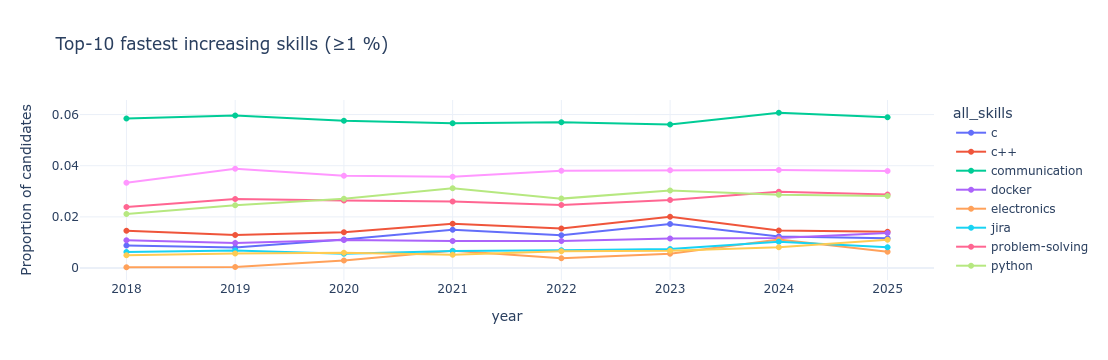

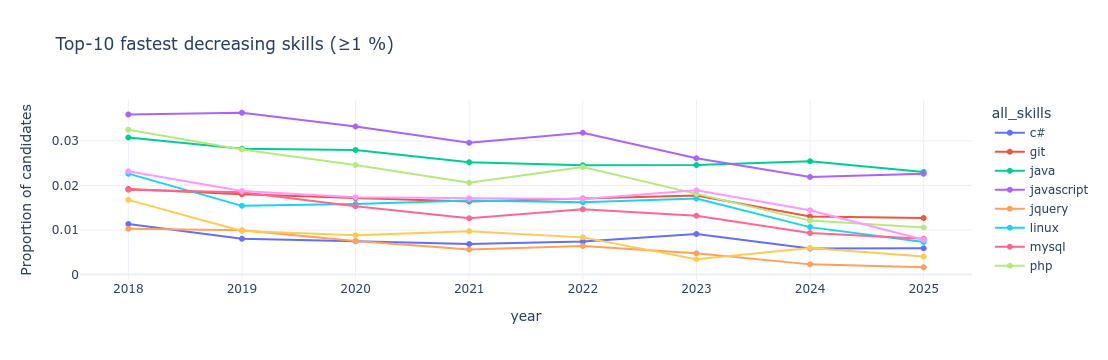

In [123]:
cand_skills = (
    df_candidates[["create_date", "all_skills"]]
      .assign(year=lambda d: d.create_date.dt.year)
      .explode("all_skills")
      .query("all_skills != '_rare_skill_'")
      .query("all_skills != '_rare_certification_'")
)

# ---------- 2. Yearly proportions ----------
totals = (
    cand_skills.groupby("year")
               .size()
               .rename("n_candidates")
)

freq = (
    cand_skills.groupby(["year", "all_skills"])
               .size()
               .rename("count")
               .reset_index()
               .merge(totals, on="year")
               .assign(prop=lambda d: d["count"] / d["n_candidates"])
)

# ---------- 3. Keep skills with ≥1 % share in at least one year ----------
kept = (
    freq.groupby("all_skills")["prop"]
        .max()
        .loc[lambda s: s >= 0.01]          # 1 % threshold
        .index
)
freq = freq.query("all_skills in @kept")

# ---------- 4. Linear slopes ----------
def slope(group):
    X = group["year"].values.reshape(-1, 1)
    y = group["prop"].values
    if len(X) < 2:
        return 0.0
    return LinearRegression().fit(X, y).coef_[0]

slopes = (
    freq.groupby("all_skills", as_index=False)
        .apply(slope)
        .rename(columns={None: "trend"})
)

top_up   = slopes.nlargest(10, "trend")["all_skills"]
top_down = slopes.nsmallest(10, "trend")["all_skills"]

inc_df = freq.query("all_skills in @top_up")
dec_df = freq.query("all_skills in @top_down")

# ---------- 5. Plot ----------
for df, title in [(inc_df, "Top-10 fastest increasing skills (≥1 %)"),
                  (dec_df, "Top-10 fastest decreasing skills (≥1 %)")]:
    fig = px.line(
        df, x="year", y="prop", color="all_skills", markers=True,
        title=title,
        labels={"prop": "Proportion of candidates"}
    )
    fig.update_layout(template="plotly_white")
    fig.show()

/tmp/ipykernel_938885/4196832635.py:44: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



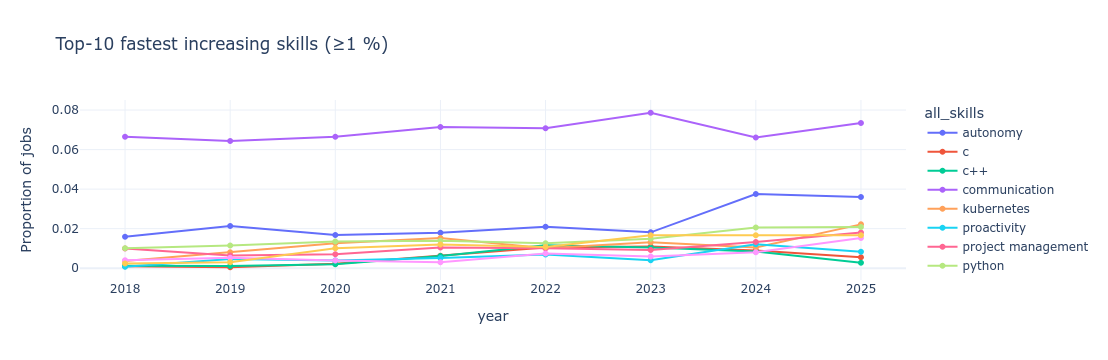

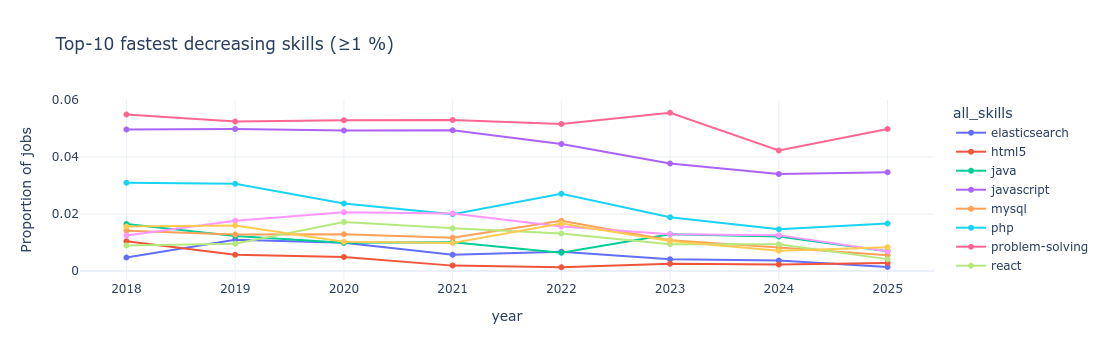

In [124]:
cand_skills = (
    df_jobs[["create_date", "all_skills"]]
      .assign(year=lambda d: d.create_date.dt.year)
      .explode("all_skills")
      .query("all_skills != '_rare_skill_'")
      .query("all_skills != '_rare_certification_'")
)

# ---------- 2. Yearly proportions ----------
totals = (
    cand_skills.groupby("year")
               .size()
               .rename("n_candidates")
)

freq = (
    cand_skills.groupby(["year", "all_skills"])
               .size()
               .rename("count")
               .reset_index()
               .merge(totals, on="year")
               .assign(prop=lambda d: d["count"] / d["n_candidates"])
)

# ---------- 3. Keep skills with ≥1 % share in at least one year ----------
kept = (
    freq.groupby("all_skills")["prop"]
        .max()
        .loc[lambda s: s >= 0.01]          # 1 % threshold
        .index
)
freq = freq.query("all_skills in @kept")

# ---------- 4. Linear slopes ----------
def slope(group):
    X = group["year"].values.reshape(-1, 1)
    y = group["prop"].values
    if len(X) < 2:
        return 0.0
    return LinearRegression().fit(X, y).coef_[0]

slopes = (
    freq.groupby("all_skills", as_index=False)
        .apply(slope)
        .rename(columns={None: "trend"})
)

top_up   = slopes.nlargest(10, "trend")["all_skills"]
top_down = slopes.nsmallest(10, "trend")["all_skills"]

inc_df = freq.query("all_skills in @top_up")
dec_df = freq.query("all_skills in @top_down")

# ---------- 5. Plot ----------
for df, title in [(inc_df, "Top-10 fastest increasing skills (≥1 %)"),
                  (dec_df, "Top-10 fastest decreasing skills (≥1 %)")]:
    fig = px.line(
        df, x="year", y="prop", color="all_skills", markers=True,
        title=title,
        labels={"prop": "Proportion of jobs"}
    )
    fig.update_layout(template="plotly_white")
    fig.show()

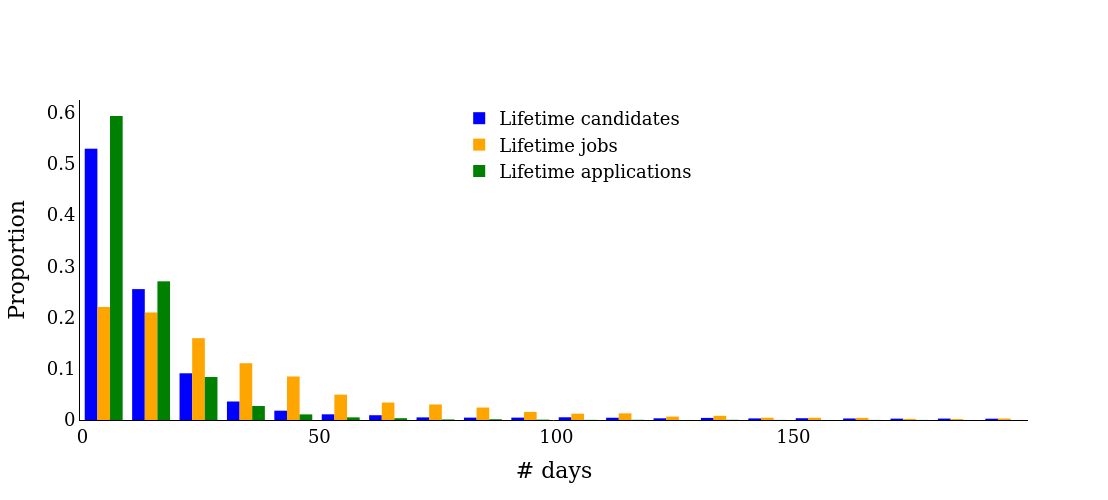

In [125]:
layout = Layout(
  #  title='Comparisation Performance With Rule Order Optimization',
    font=dict(family='Latin Modern Math', size=18, color="black"),
    xaxis=dict(
        title='# days',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    yaxis=dict(
        title='Proportion',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    legend=dict(x=0.4, y=1),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    width=600, height=500
)
data = [
    Histogram(x=[x.days for x in lifetime_candidate if x.days < 200],
              nbinsx=20, name="Lifetime candidates", histnorm='probability', marker_color="blue"),
    Histogram(x=[x.days for x in lifetime_job if x.days < 200],
              nbinsx=20, name="Lifetime jobs", histnorm='probability', marker_color="orange"),
    Histogram(x=[x.days for x in lifetime_application if x.days < 200],
              nbinsx=20, name="Lifetime applications", histnorm='probability', marker_color="green")
]
fig = Figure(data=data, layout=layout)
fig.show()
fig.write_image("lifetimes.pdf")

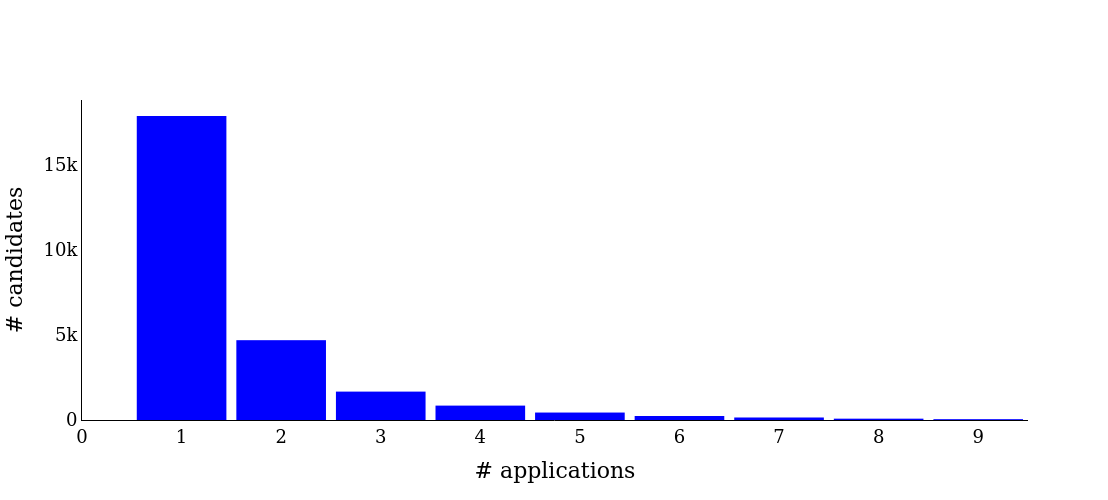

In [126]:
layout = Layout(
  #  title='Comparisation Performance With Rule Order Optimization',
    font=dict(family='Latin Modern Math', size=18, color="black"),
    xaxis=dict(
        title='# applications',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    yaxis=dict(
        title='# candidates',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    legend=dict(x=0.4, y=1),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    width=600, height=500, bargap=0.1
)
data = [
    Histogram(x=[x for x in df_hist.groupby(by="candidate_id")["job_id"].count().dropna() if x < 10], marker_color="blue")
]
fig = Figure(data=data, layout=layout)
fig.show()
fig.write_image("candidates_applications.pdf")

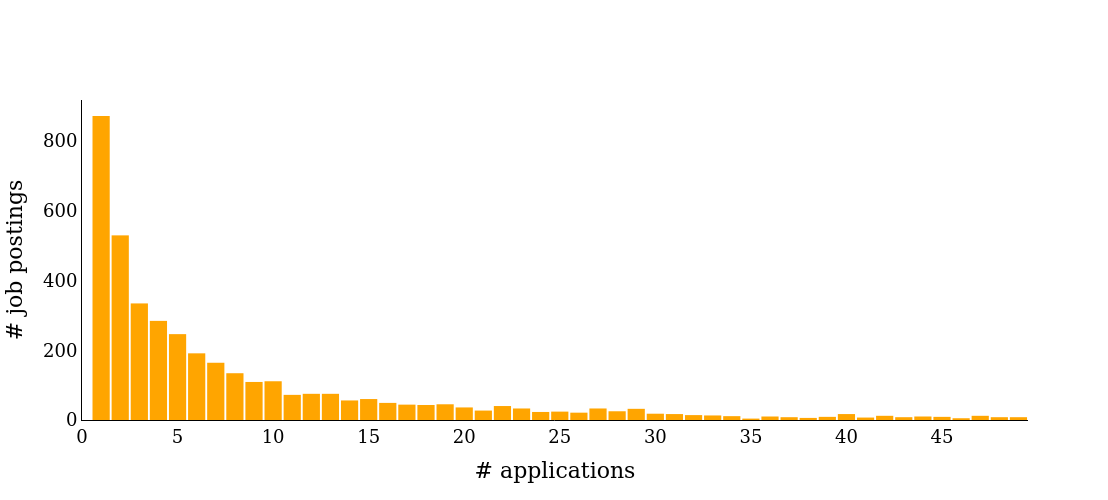

In [127]:
layout = Layout(
  #  title='Comparisation Performance With Rule Order Optimization',
    font=dict(family='Latin Modern Math', size=18, color="black"),
    xaxis=dict(
        title='# applications',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    yaxis=dict(
        title='# job postings',
        autorange=True,
        showgrid=False,
        zeroline=True,
        showline=True,
        ticks='',
        linecolor='black',
        showticklabels=True,
        rangemode="tozero"
    ),
    legend=dict(x=0.4, y=1),
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)',
    width=600, height=500, bargap=0.1
)
data = [
    Histogram(x=[x for x in df_hist.groupby(by="job_id").count()["candidate_id"] if x < 50], marker_color="orange")
]
fig = Figure(data=data, layout=layout)
fig.show()
fig.write_image("jobs_applications.pdf")

In [128]:
print("Average number of applications per candidate", df_hist.groupby(by="candidate_id")["job_id"].count().mean())

Average number of applications per candidate 1.620167809662465


In [129]:
print("Average number of applications per job", df_hist.groupby(by="job_id")["candidate_id"].count().mean())

Average number of applications per job 10.274052478134111


In [173]:
skills = []
for x in df_candidates["all_skills"]:
    for y in x:
        if y != "_rare_skill_" and y != "_rare_certification_":
            if y == "problem solving":
                y = "problem-solving"
            y = y.replace(".js", "").replace("amazon web services", "was").replace("css3", "css")
            if y.startswith("agile"):
                y = "agile"
            skills.append(y)

In [178]:
wordcloud =  WordCloud(background_color="white", regexp=r"[^;]*", collocations=False, colormap="copper").generate(";".join(skills))

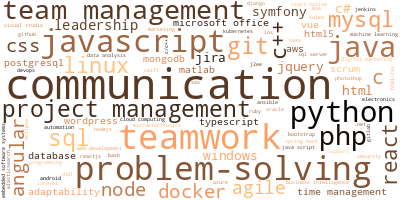

In [179]:
wordcloud.to_image()

In [180]:
with open("wordcloud.svg", "w") as f:
    f.write(wordcloud.to_svg())

In [182]:
import geopandas as gpd
sf = gpd.read_file('departements-version-simplifiee.geojson')
sf.head()

,code,nom,geometry
0,01,Ain,"POLYGON ((4.78021 46.17668, 4.79458 46.21832, ..."
1,02,Aisne,"POLYGON ((4.04797 49.40564, 4.03991 49.3974, 4..."
2,03,Allier,"POLYGON ((3.03207 46.79491, 3.04907 46.75808, ..."
3,04,Alpes-de-Haute-Provence,"POLYGON ((5.67604 44.19143, 5.69209 44.18648, ..."
4,05,Hautes-Alpes,"POLYGON ((6.26057 45.12685, 6.29922 45.10855, ..."


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
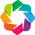

In [183]:
import geoviews as gv
import geoviews.feature as gf
from geoviews import dim
import holoviews as hv
from bokeh.io import export_svgs
gv.extension('bokeh')

In [194]:
zips = Counter(df_jobs["zipcode"].dropna().astype(int, errors = 'ignore'))
values = [np.log(zips.get(str(int(x)), 1)) if x.isdigit() else 0 for x in sf["code"]]
sf["values"] = values
job_deps = gv.Polygons(sf, vdims=['nom','values'])
job_deps.opts(width=3000, height=3000, toolbar='above', color=dim('values'),
          colorbar=True, tools=['hover'], aspect='equal', xaxis=None, yaxis=None)

:Polygons   [Longitude,Latitude]   (nom,values)

In [197]:
zips = dict([(int(float(x)), y) for x, y in Counter(df_candidates["zipcode"].dropna().astype(int)).items()])
values = [np.log(zips.get(int(x), 1)) if x.isdigit() else 0 for x in sf["code"]]
sf["values"] = values
deps = gv.Polygons(sf, vdims=['nom','values'])
deps.opts(width=3000, height=3000, toolbar='above', color=dim('values'),
          colorbar=True, tools=['hover'], aspect='equal', xaxis=None, yaxis=None)

:Polygons   [Longitude,Latitude]   (nom,values)